# Pipeline 2: Donor Churn Prediction

**Organization:** A nonprofit dedicated to protecting Native American women and girls from sexual abuse  
**Database schema:** `lighthouse` (AWS RDS PostgreSQL)  
**Target variable:** `churned` (binary: 1 = lapsed donor, 0 = retained)  
**Notebook purpose:** Full exploratory and modeling narrative — from raw donor data to a deployed ONNX model that surfaces churn risk scores in the donor management dashboard

---

*This notebook is self-contained and runs top-to-bottom given a working PostgreSQL connection configured in the project `.env` file.*

## 1. Business Understanding

### Organizational Context

This nonprofit serves Native American women and girls who have experienced or are at risk of sexual abuse. Its programs — crisis intervention, survivor housing, counseling, and community education — depend **entirely on charitable donations**. There is no government contract funding, no endowment, and no earned revenue. Every program the organization runs exists because a donor chose to give, and continued to give.

The organization has roughly 60 donors in its database. That is not a misprint. This is a small, relationship-driven donor base where each individual supporter represents a meaningful fraction of total annual revenue. Losing even three or four mid-level donors without warning can force a program cancellation or a staffing reduction.

### The Problem

The Executive Director currently has no system for identifying which donors are drifting away. Donors who used to give annually quietly stop. The organization learns they have lapsed only when the next solicitation cycle goes unanswered. By that point, re-engagement is much harder — the emotional connection has cooled, another cause has filled the gap, and the donor may feel neglected.

Leadership wants to know:

1. **Who is at risk of lapsing before they actually lapse?** (Predict churn probability before the next solicitation cycle so staff can call proactively.)
2. **What distinguishes engaged donors from churned donors?** (Understand the features — acquisition channel, donation type, program focus — that predict retention, so outreach can be personalized and acquisition strategy can be refined.)

### Dual Goals: Predictive and Explanatory

This pipeline has two complementary objectives:

| Goal | Model Type | Deployed? |
|------|-----------|----------|
| **Predictive**: flag donors most likely to churn in the next 12 months | LogisticRegression or RandomForest (best ROC-AUC wins) | Yes — ONNX to C# donor dashboard |
| **Explanatory**: understand what organizational behaviors and donor characteristics drive churn | Logistic Regression coefficients (odds ratios) | No — notebook artifact for strategic insight |

### Why This Is Hard

- **Tiny dataset.** ~60 supporters means any model will have wide confidence intervals. We treat this as a screening tool, not a definitive classifier.
- **Class imbalance.** Depending on the churn cutoff, one class may dominate. We use `class_weight='balanced'` and report F1/recall rather than accuracy.
- **No direct survey data.** We cannot ask donors why they left. We must infer from behavioral signals in the donation history.
- **Data leakage risk.** `supporters.status` (Active/Inactive) is a direct proxy for the target — it must not be used as a feature.

### Stakeholders

- **Executive Director:** Needs a ranked list of at-risk donors each quarter so she can prioritize personal outreach calls.
- **Donor Outreach Coordinator:** Needs to understand which acquisition channels attract sticky donors vs. one-time givers, so stewardship energy goes to the right people.
- **Board:** Needs aggregate churn rate trends to assess organizational health.

### Success Criteria

- ROC-AUC > 0.70 (meaningful signal given ~60 rows)
- Recall for churned class > 0.65 (catching lapsed donors matters more than avoiding false alarms)
- Actionable coefficient table from Logistic Regression
- Deployed ONNX model that loads in the C# donor management dashboard

## 2. Data Acquisition and Preparation

In [1]:
import sys
from pathlib import Path

# Walk up from cwd until we find the is455/ml-pipelines directory
ROOT = Path.cwd()
for _ in range(8):
    ml_path = ROOT / 'is455' / 'ml-pipelines'
    if ml_path.exists():
        break
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / 'is455' / 'ml-pipelines'))

from utils.db_loader import get_engine, load_table

engine = get_engine()
print('Database connection established.')

Database connection established.


In [2]:
# ── Resolve project root and load utilities ───────────────────────────────────
ROOT = Path.cwd()
for _ in range(8):
    if (ROOT / 'is455' / 'ml-pipelines').exists():
        break
    ROOT = ROOT.parent

MLPIPELINES = ROOT / 'is455' / 'ml-pipelines'
sys.path.insert(0, str(MLPIPELINES))

from utils.db_loader import get_engine, load_table
from utils.onnx_exporter import export_to_onnx, verify_onnx

print(f'Project root: {ROOT}')
print(f'ml-pipelines: {MLPIPELINES}')

Project root: /Users/nathanblatter/Desktop/INTEX-II
ml-pipelines: /Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

DATASET_END   = pd.Timestamp('2026-03-01')
CHURN_CUTOFF  = pd.Timestamp('2025-03-01')  # 12-month lookback window

print(f'Dataset end date  : {DATASET_END.date()}')
print(f'Churn cutoff date : {CHURN_CUTOFF.date()}')

Dataset end date  : 2026-03-01
Churn cutoff date : 2025-03-01


In [4]:
supporters          = load_table(engine, 'supporters')
donations           = load_table(engine, 'donations')
donation_allocations = load_table(engine, 'donation_allocations')

print(f'supporters          : {supporters.shape}')
print(f'donations           : {donations.shape}')
print(f'donation_allocations: {donation_allocations.shape}')
print()
print('supporters columns :', list(supporters.columns))
print('donations columns  :', list(donations.columns))

supporters          : (60, 15)
donations           : (420, 13)
donation_allocations: (521, 7)

supporters columns : ['supporter_id', 'supporter_type', 'display_name', 'organization_name', 'first_name', 'last_name', 'relationship_type', 'region', 'country', 'email', 'phone', 'status', 'created_at', 'first_donation_date', 'acquisition_channel']
donations columns  : ['donation_id', 'supporter_id', 'donation_type', 'donation_date', 'is_recurring', 'campaign_name', 'channel_source', 'currency_code', 'amount', 'estimated_value', 'impact_unit', 'notes', 'referral_post_id']


In [5]:
# Parse dates
donations['donation_date']  = pd.to_datetime(donations['donation_date'])
supporters['created_at']    = pd.to_datetime(supporters['created_at'])
if 'first_donation_date' in supporters.columns:
    supporters['first_donation_date'] = pd.to_datetime(supporters['first_donation_date'])

print(f'Donation date range: {donations["donation_date"].min().date()} to {donations["donation_date"].max().date()}')
print(f'Unique supporters with donations: {donations["supporter_id"].nunique()}')

Donation date range: 2023-01-09 to 2026-03-01
Unique supporters with donations: 59


### Build the Churn Label

**Definition:** A donor is marked `churned = 1` if their most recent donation occurred before **2025-03-01** (12 months before the dataset end date of 2026-03-01). Donors who gave at least once on or after that cutoff are considered retained (`churned = 0`).

This is a standard LYBUNT (Lapsed Year But Unfortunately Not This year) window commonly used in nonprofit fundraising analytics.

In [6]:
last_donation = (
    donations.groupby('supporter_id')['donation_date']
    .max()
    .reset_index()
    .rename(columns={'donation_date': 'last_donation_date'})
)
last_donation['churned'] = (last_donation['last_donation_date'] < CHURN_CUTOFF).astype(int)

print('Churn label distribution:')
print(last_donation['churned'].value_counts().rename({0: 'Retained (0)', 1: 'Churned (1)'})
      .to_frame('count'))

Churn label distribution:
              count
churned            
Retained (0)     51
Churned (1)       8


### Validate Labels Against supporters.status

`supporters.status` (Active / Inactive) is a direct proxy for the churn label and **must not be used as a feature** — that would be data leakage. However, we cross-reference it here to validate that our label construction is coherent. We expect: most `churned = 1` supporters will have `status = Inactive`, and most `churned = 0` will be `Active`.

In [7]:
if 'status' in supporters.columns:
    validation = last_donation.merge(supporters[['supporter_id', 'status']], on='supporter_id', how='left')
    cross_tab = pd.crosstab(validation['churned'], validation['status'],
                            rownames=['churned'], colnames=['supporters.status'])
    print('Cross-tabulation: churn label vs supporters.status (validation only — status NOT used as feature)')
    display(cross_tab)
else:
    print('supporters.status column not found — skipping validation cross-tab.')

Cross-tabulation: churn label vs supporters.status (validation only — status NOT used as feature)


supporters.status,Active,Inactive
churned,,
0,39,12
1,5,3


## 3. Exploratory Data Analysis

### Missingness and Outlier AuditBefore modeling, we check two things that usually trip up donor-churn pipelines:1. **Missingness** — any feature missing more than ~20% of values is suspect. We   either impute with a domain-justified default or drop the feature.2. **Outliers** — a single mega-donor with \$50k lifetime giving will dominate   `monetary_total` and mask patterns in the rest of the data. We inspect the   distribution and log-transform monetary features inside the modeling pipeline   (handled by the `StandardScaler` + numeric transformer).

In [ ]:
# Missingness report on the joined supporter-level view
missing_pct = (eda_rfm.isna().mean() * 100).sort_values(ascending=False)
print('Missingness per column (%):')
print(missing_pct[missing_pct > 0].round(1).to_string() if (missing_pct > 0).any()
      else '  (none — every column fully populated)')
print()

# Outlier check on monetary_total — how skewed is the donor base?
mt = eda_rfm['monetary_total']
print(f'monetary_total  min: ${mt.min():,.0f}')
print(f'                median: ${mt.median():,.0f}')
print(f'                mean:   ${mt.mean():,.0f}')
print(f'                max:    ${mt.max():,.0f}')
print(f'                skew:   {mt.skew():.2f}   (>1 = heavy right tail)')

In [8]:
# Build a quick RFM frame for EDA
donations['is_recurring_bool'] = (
    donations['is_recurring']
    .map({True: 1, False: 0, 'True': 1, 'False': 0, 1: 1, 0: 0})
    .fillna(0).astype(int)
)

eda_rfm = donations.groupby('supporter_id').agg(
    last_donation_date=('donation_date', 'max'),
    frequency=('donation_id', 'count'),
    monetary_total=('estimated_value', 'sum'),
    monetary_avg=('estimated_value', 'mean'),
    has_recurring=('is_recurring_bool', 'max'),
).reset_index()

eda_rfm['recency_days'] = (DATASET_END - eda_rfm['last_donation_date']).dt.days
eda_rfm = eda_rfm.merge(last_donation[['supporter_id', 'churned']], on='supporter_id', how='left')
eda_rfm['churn_label'] = eda_rfm['churned'].map({0: 'Retained', 1: 'Churned'})

print(f'EDA frame: {eda_rfm.shape}')
eda_rfm.head()

EDA frame: (59, 9)


,supporter_id,last_donation_date,frequency,monetary_total,monetary_avg,has_recurring,recency_days,churned,churn_label
0,1,2026-02-19,12,9000.03,750.002500,1,10,0,Retained
1,2,2025-05-08,4,3877.36,969.340000,0,297,0,Retained
2,3,2025-09-13,16,12448.13,778.008125,1,169,0,Retained
3,4,2026-03-01,11,9934.62,903.147273,1,0,0,Retained
4,5,2025-10-02,5,4751.17,950.234000,0,150,0,Retained


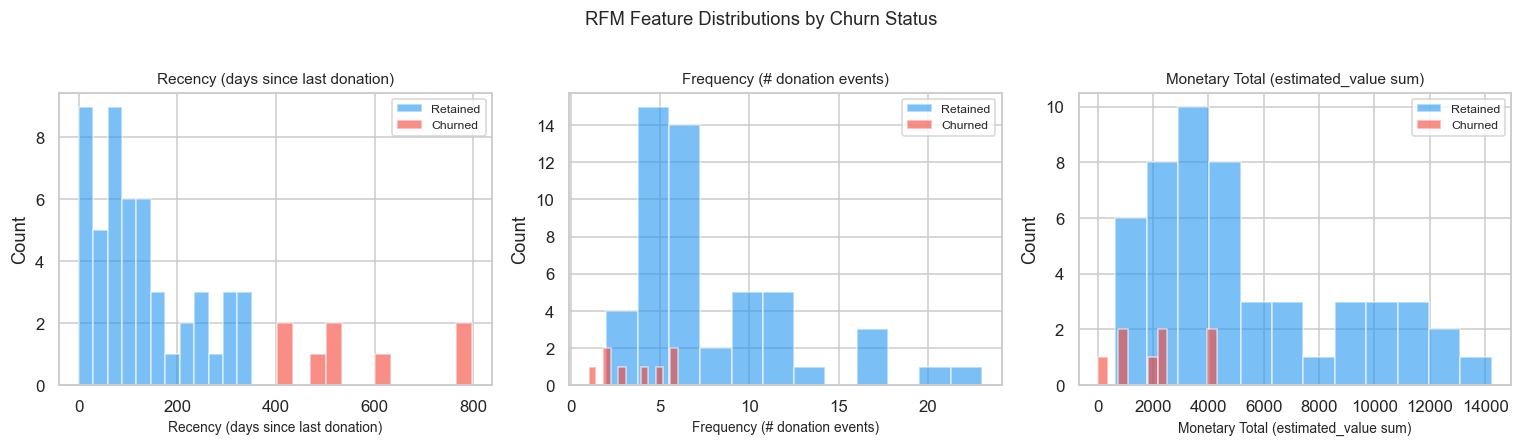

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

rfm_plot_cols = [
    ('recency_days',    'Recency (days since last donation)'),
    ('frequency',       'Frequency (# donation events)'),
    ('monetary_total',  'Monetary Total (estimated_value sum)'),
]

for ax, (col, label) in zip(axes, rfm_plot_cols):
    for churn_val, color in [(0, '#2196F3'), (1, '#F44336')]:
        subset = eda_rfm[eda_rfm['churned'] == churn_val][col].dropna()
        churn_str = 'Retained' if churn_val == 0 else 'Churned'
        ax.hist(subset, bins=12, alpha=0.6, color=color, label=churn_str, edgecolor='white')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Count')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle('RFM Feature Distributions by Churn Status', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

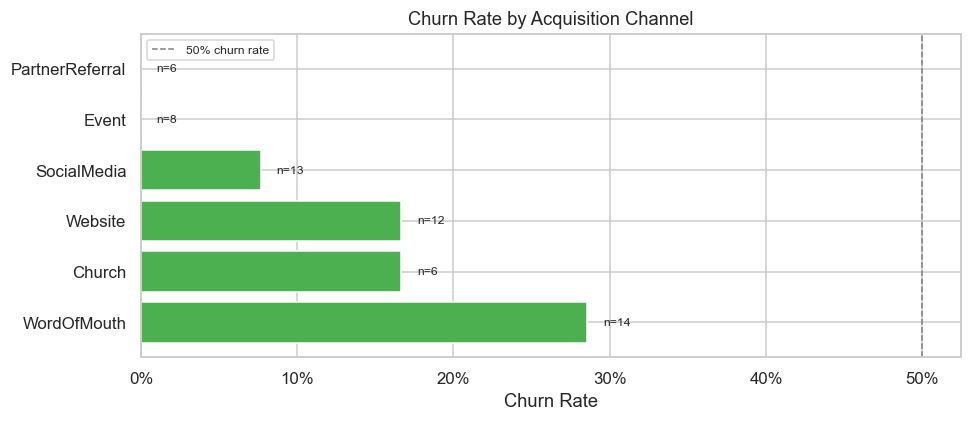

acquisition_channel  churn_rate  n_donors
        WordOfMouth    0.285714        14
             Church    0.166667         6
            Website    0.166667        12
        SocialMedia    0.076923        13
              Event    0.000000         8
    PartnerReferral    0.000000         6


In [10]:
# Acquisition channel breakdown
if 'acquisition_channel' in supporters.columns:
    eda_supp = eda_rfm.merge(supporters[['supporter_id', 'acquisition_channel']], on='supporter_id', how='left')
    channel_churn = (
        eda_supp.groupby('acquisition_channel')['churned']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'churn_rate', 'count': 'n_donors'})
        .sort_values('churn_rate', ascending=False)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ['#F44336' if r > 0.5 else '#4CAF50' for r in channel_churn['churn_rate']]
    bars = ax.barh(channel_churn['acquisition_channel'], channel_churn['churn_rate'], color=colors)
    for bar, n in zip(bars, channel_churn['n_donors']):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f'n={n}', va='center', fontsize=8)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='50% churn rate')
    ax.set_xlabel('Churn Rate')
    ax.set_title('Churn Rate by Acquisition Channel')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    print(channel_churn.to_string(index=False))
else:
    print('acquisition_channel column not present in supporters.')

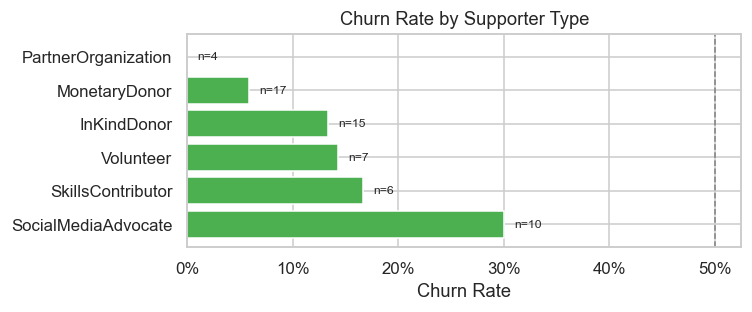

     supporter_type  churn_rate  n_donors
SocialMediaAdvocate    0.300000        10
  SkillsContributor    0.166667         6
          Volunteer    0.142857         7
        InKindDonor    0.133333        15
      MonetaryDonor    0.058824        17
PartnerOrganization    0.000000         4


In [11]:
# Donor type breakdown
if 'supporter_type' in supporters.columns:
    eda_supp2 = eda_rfm.merge(supporters[['supporter_id', 'supporter_type']], on='supporter_id', how='left')
    type_churn = (
        eda_supp2.groupby('supporter_type')['churned']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'churn_rate', 'count': 'n_donors'})
        .sort_values('churn_rate', ascending=False)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(7, 3))
    colors2 = ['#F44336' if r > 0.5 else '#4CAF50' for r in type_churn['churn_rate']]
    bars2 = ax.barh(type_churn['supporter_type'], type_churn['churn_rate'], color=colors2)
    for bar, n in zip(bars2, type_churn['n_donors']):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f'n={n}', va='center', fontsize=8)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Churn Rate')
    ax.set_title('Churn Rate by Supporter Type')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    plt.tight_layout()
    plt.show()

    print(type_churn.to_string(index=False))

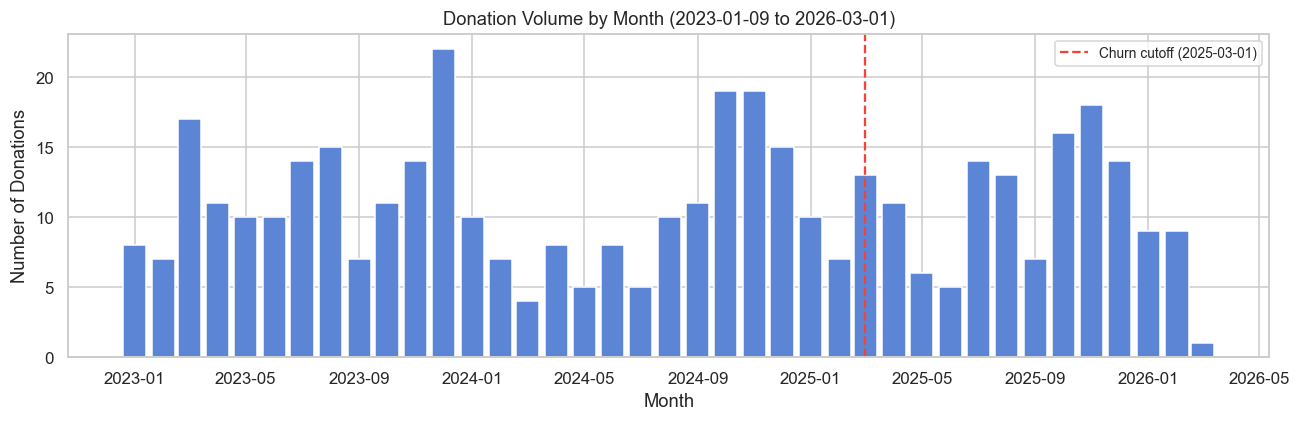

In [12]:
# Time series: donation counts by month
donations['month'] = donations['donation_date'].dt.to_period('M')
monthly = donations.groupby('month')['donation_id'].count().reset_index()
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly['month_dt'], monthly['donation_id'], width=25, color='#5C85D6', edgecolor='white')
ax.axvline(CHURN_CUTOFF, color='#F44336', linestyle='--', linewidth=1.5, label='Churn cutoff (2025-03-01)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Donations')
ax.set_title('Donation Volume by Month (2023-01-09 to 2026-03-01)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

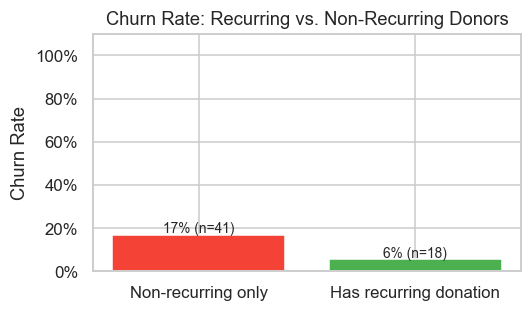


Recurring donor churn summary:
   has_recurring_label  churn_rate  n_donors
    Non-recurring only    0.170732        41
Has recurring donation    0.055556        18


In [13]:
# Recurring donor churn comparison
recurring_churn = eda_rfm.groupby('has_recurring')['churned'].agg(['mean', 'count']).reset_index()
recurring_churn['has_recurring_label'] = recurring_churn['has_recurring'].map({0: 'Non-recurring only', 1: 'Has recurring donation'})

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(recurring_churn['has_recurring_label'], recurring_churn['mean'],
       color=['#F44336', '#4CAF50'])
for i, (rate, n) in enumerate(zip(recurring_churn['mean'], recurring_churn['count'])):
    ax.text(i, rate + 0.01, f'{rate:.0%} (n={n})', ha='center', fontsize=9)
ax.set_ylabel('Churn Rate')
ax.set_title('Churn Rate: Recurring vs. Non-Recurring Donors')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

print('\nRecurring donor churn summary:')
print(recurring_churn[['has_recurring_label', 'mean', 'count']].rename(
    columns={'mean': 'churn_rate', 'count': 'n_donors'}).to_string(index=False))

## 4. Feature Engineering

We construct one row per supporter with features from three sources:

1. **RFM from donations** — behavioral signals from the donation history
2. **Static from supporters** — demographic/organizational attributes (no leaky columns)
3. **Program allocation features** — where each donor's money has gone

### Rationale for Each Feature Group

| Feature | Source | Rationale |
|---------|--------|-----------|
| `recency_days` | donations | Most powerful churn signal — donors who haven't given in a long time are at high risk |
| `frequency` | donations | More touch-points = stronger habit and relationship |
| `monetary_total / avg / max` | donations | High-value donors tend to have stronger organizational ties; use `estimated_value` to cover non-cash gifts |
| `has_recurring` | donations | Recurring donors almost never churn — strongest binary signal |
| `recurring_rate` | donations | Proportion of donations that are recurring |
| `donation_types_count` | donations | Donors who give in multiple ways (recurring + one-time + event) are more deeply engaged |
| `days_since_first` | donations | Tenure of donation relationship, independent of supporter creation date |
| `donation_velocity` | donations | Donations per day — captures cadence |
| `has_campaign_donation` | donations | Campaign givers may be episodic rather than habitual |
| `tenure_days` | supporters | How long they've been in the database; longer tenure correlates with loyalty |
| `supporter_type`, `acquisition_channel`, `relationship_type`, `region` | supporters | Categorical attributes that proxy for how the donor found the org and their relationship depth |
| `pct_education / pct_health / pct_counseling` | donation_allocations | Program affinity — donors with strong affinity to a specific program area may churn if that program changes |
| `unique_safehouses_funded` | donation_allocations | Breadth of impact investment; donors funding multiple safehouses are more embedded |

**Excluded columns (data leakage / PII):** `status`, `email`, `phone`, `display_name`, `first_name`, `last_name`, `organization_name`

In [14]:
# --- RFM features ---
rfm = donations.groupby('supporter_id').agg(
    last_donation_date=('donation_date', 'max'),
    first_donation_date=('donation_date', 'min'),
    frequency=('donation_id', 'count'),
    monetary_total=('estimated_value', 'sum'),
    monetary_avg=('estimated_value', 'mean'),
    monetary_max=('estimated_value', 'max'),
    has_recurring=('is_recurring_bool', 'max'),
    recurring_sum=('is_recurring_bool', 'sum'),
    donation_types_count=('donation_type', 'nunique'),
).reset_index()

rfm['recency_days']     = (DATASET_END - rfm['last_donation_date']).dt.days
rfm['days_since_first'] = (DATASET_END - rfm['first_donation_date']).dt.days
rfm['donation_velocity'] = rfm['frequency'] / rfm['days_since_first'].replace(0, np.nan)
rfm['donation_velocity'] = rfm['donation_velocity'].fillna(0)
rfm['recurring_rate']    = rfm['recurring_sum'] / rfm['frequency'].replace(0, np.nan)
rfm['recurring_rate']    = rfm['recurring_rate'].fillna(0)

# has_campaign_donation
campaign_flag = (
    donations[donations['campaign_name'].notna()]
    .groupby('supporter_id')['donation_id'].count()
    .reset_index(name='campaign_count')
)
campaign_flag['has_campaign_donation'] = 1
rfm = rfm.merge(campaign_flag[['supporter_id', 'has_campaign_donation']], on='supporter_id', how='left')
rfm['has_campaign_donation'] = rfm['has_campaign_donation'].fillna(0).astype(int)
rfm = rfm.drop(columns=['last_donation_date', 'first_donation_date', 'recurring_sum'])

print(f'RFM frame: {rfm.shape}')
rfm.describe().round(2)

RFM frame: (59, 12)


,supporter_id,frequency,monetary_total,monetary_avg,monetary_max,has_recurring,donation_types_count,recency_days,days_since_first,donation_velocity,recurring_rate,has_campaign_donation
count,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00
mean,30.54,7.12,4978.10,702.59,1743.97,0.31,2.88,185.54,951.85,0.01,0.31,0.92
std,17.61,4.51,3542.86,375.78,1030.90,0.46,0.93,186.85,195.78,0.00,0.46,0.28
min,1.00,1.00,27.12,27.12,27.12,0.00,1.00,0.00,388.00,0.00,0.00,0.00
25%,15.50,4.00,2211.99,464.23,1129.48,0.00,2.00,59.50,827.00,0.00,0.00,1.00
50%,31.00,6.00,3976.01,676.77,1564.35,0.00,3.00,118.00,1025.00,0.01,0.00,1.00
75%,45.50,9.00,6951.16,846.22,2119.35,1.00,3.00,267.50,1091.00,0.01,1.00,1.00
max,60.00,23.00,14240.29,2356.92,6481.54,1.00,5.00,797.00,1147.00,0.02,1.00,1.00


In [15]:
# --- Allocation features ---
alloc = donation_allocations.merge(
    donations[['donation_id', 'supporter_id']], on='donation_id', how='left'
).dropna(subset=['supporter_id'])

alloc_agg = alloc.groupby('supporter_id').agg(
    total_allocated=('amount_allocated', 'sum'),
    unique_safehouses_funded=('safehouse_id', 'nunique'),
).reset_index()

alloc['program_area_lower'] = alloc['program_area'].fillna('').str.lower()

for col, pattern in [
    ('alloc_education', 'education'),
    ('alloc_health',    'health|wellbeing'),
    ('alloc_counseling','counsel|case'),
]:
    sub = (
        alloc[alloc['program_area_lower'].str.contains(pattern, regex=True)]
        .groupby('supporter_id')['amount_allocated'].sum()
        .reset_index(name=col)
    )
    alloc_agg = alloc_agg.merge(sub, on='supporter_id', how='left')

for col in ['alloc_education', 'alloc_health', 'alloc_counseling']:
    alloc_agg[col] = alloc_agg[col].fillna(0)

total_safe = alloc_agg['total_allocated'].replace(0, np.nan)
alloc_agg['pct_education']  = alloc_agg['alloc_education']  / total_safe
alloc_agg['pct_health']     = alloc_agg['alloc_health']     / total_safe
alloc_agg['pct_counseling'] = alloc_agg['alloc_counseling'] / total_safe
alloc_agg[['pct_education', 'pct_health', 'pct_counseling']] = (
    alloc_agg[['pct_education', 'pct_health', 'pct_counseling']].fillna(0)
)
alloc_agg = alloc_agg.drop(columns=['alloc_education', 'alloc_health', 'alloc_counseling', 'total_allocated'])

print(f'Allocation features: {alloc_agg.shape}')
alloc_agg.head()

Allocation features: (59, 5)


,supporter_id,unique_safehouses_funded,pct_education,pct_health,pct_counseling
0,1,9,0.284711,0.367619,0.0
1,2,6,0.333909,0.000000,0.0
2,3,8,0.173417,0.023877,0.0
3,4,7,0.316824,0.377939,0.0
4,5,4,0.108910,0.000000,0.0


In [16]:
# --- Static supporter features ---
supporters_feat = supporters.copy()
supporters_feat['tenure_days'] = (DATASET_END - supporters_feat['created_at']).dt.days

leaky_cols = ['status', 'email', 'phone', 'display_name',
              'first_name', 'last_name', 'organization_name',
              'first_donation_date', 'created_at']

static_cols = ['supporter_id', 'tenure_days',
               'supporter_type', 'acquisition_channel', 'relationship_type', 'region', 'country']
static_df = supporters_feat[[c for c in static_cols if c in supporters_feat.columns]].copy()

# Drop country if too many unique values
if 'country' in static_df.columns:
    n_countries = static_df['country'].nunique()
    print(f'country unique values: {n_countries}')
    if n_countries > 20:
        static_df = static_df.drop(columns=['country'])
        print('  Dropped country (too many categories).')

print(f'Static features: {static_df.shape}')
static_df.head()

country unique values: 4
Static features: (60, 7)


,supporter_id,tenure_days,supporter_type,acquisition_channel,relationship_type,region,country
0,1,1520,SocialMediaAdvocate,SocialMedia,Local,Luzon,Philippines
1,2,1515,Volunteer,SocialMedia,Local,Mindanao,Philippines
2,3,1510,MonetaryDonor,SocialMedia,Local,Luzon,Philippines
3,4,1505,MonetaryDonor,Church,PartnerOrganization,Mindanao,Philippines
4,5,1500,InKindDonor,Website,PartnerOrganization,Mindanao,Philippines


In [17]:
# --- Merge all features ---
df = (
    last_donation[['supporter_id', 'churned']]
    .merge(rfm,         on='supporter_id', how='left')
    .merge(alloc_agg,   on='supporter_id', how='left')
    .merge(static_df,   on='supporter_id', how='left')
)

# Fill all numeric NaN with 0
numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols_all] = df[numeric_cols_all].fillna(0)

print(f'Final merged dataset: {df.shape}')
print(f'Churn rate: {df["churned"].mean():.1%} ({df["churned"].sum()} churned / {len(df)} total)')
df.head()

Final merged dataset: (59, 23)
Churn rate: 13.6% (8 churned / 59 total)


,supporter_id,churned,frequency,monetary_total,monetary_avg,monetary_max,has_recurring,donation_types_count,recency_days,days_since_first,...,unique_safehouses_funded,pct_education,pct_health,pct_counseling,tenure_days,supporter_type,acquisition_channel,relationship_type,region,country
0,1,0,12,9000.03,750.002500,2628.14,1,3,10,1072,...,9,0.284711,0.367619,0.0,1520,SocialMediaAdvocate,SocialMedia,Local,Luzon,Philippines
1,2,0,4,3877.36,969.340000,2565.03,0,3,297,1089,...,6,0.333909,0.000000,0.0,1515,Volunteer,SocialMedia,Local,Mindanao,Philippines
2,3,0,16,12448.13,778.008125,2133.99,1,4,169,1103,...,8,0.173417,0.023877,0.0,1510,MonetaryDonor,SocialMedia,Local,Luzon,Philippines
3,4,0,11,9934.62,903.147273,2667.25,1,2,0,1082,...,7,0.316824,0.377939,0.0,1505,MonetaryDonor,Church,PartnerOrganization,Mindanao,Philippines
4,5,0,5,4751.17,950.234000,2022.07,0,2,150,802,...,4,0.108910,0.000000,0.0,1500,InKindDonor,Website,PartnerOrganization,Mindanao,Philippines


In [18]:
# Define feature lists for the sklearn pipeline
categorical_features = [
    c for c in ['supporter_type', 'acquisition_channel', 'relationship_type', 'region', 'country']
    if c in df.columns
]
exclude_cols = {'supporter_id', 'churned'} | set(categorical_features)
numeric_features = [c for c in df.columns if c not in exclude_cols]

X = df[numeric_features + categorical_features].copy()
y = df['churned'].astype(int)

print(f'Feature matrix: {X.shape}')
print(f'Numeric features  ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Feature matrix: (59, 21)
Numeric features  (16): ['frequency', 'monetary_total', 'monetary_avg', 'monetary_max', 'has_recurring', 'donation_types_count', 'recency_days', 'days_since_first', 'donation_velocity', 'recurring_rate', 'has_campaign_donation', 'unique_safehouses_funded', 'pct_education', 'pct_health', 'pct_counseling', 'tenure_days']
Categorical features (5): ['supporter_type', 'acquisition_channel', 'relationship_type', 'region', 'country']


### Why StratifiedKFold Instead of a Single Train/Test SplitWith only ~60 supporters and a ~14% churn rate, a single 80/20 split would put**~8 churned donors** in the test set. That is not enough signal to trust anymetric. Two specific failure modes:- **Metric variance**: one lucky / unlucky split could move ROC-AUC by ±0.15  and we'd never know which number to believe.- **Class imbalance in the test fold**: a random 20% split could easily end up  with 1-2 churned donors, making precision and recall essentially undefined.`StratifiedKFold(n_splits=5)` keeps the churn rate balanced across every foldand gives us five independent estimates of ROC-AUC that we can average andreport a standard deviation for. This is the textbook prescription for small,imbalanced datasets (Ch. 15). We use the same folds for both the LogisticRegression and Random Forest grid searches so the comparison is fair.

## 5. Model Training and Evaluation

We train two classifier pipelines and select the one with higher cross-validated ROC-AUC:

1. **Logistic Regression** — interpretable, produces odds ratios, works well with small datasets and balanced classes
2. **Random Forest** — handles non-linear interactions and is more robust to outliers

Both use `class_weight='balanced'` to compensate for class imbalance. We tune hyperparameters with `GridSearchCV` and evaluate with `StratifiedKFold(k=5)`.

**Primary metrics:** ROC-AUC, F1, Precision, Recall — NOT accuracy (accuracy is uninformative with imbalanced classes).

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_preprocessor(num_feats, cat_feats):
    return ColumnTransformer(transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
        ]), num_feats),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), cat_feats),
    ])

print('Preprocessor defined.')

Preprocessor defined.


In [20]:
# --- Logistic Regression grid search ---
lr_pipe = Pipeline([
    ('preprocessor', make_preprocessor(numeric_features, categorical_features)),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)),
])

lr_grid = GridSearchCV(
    lr_pipe,
    param_grid={'model__C': [0.01, 0.1, 0.5, 1.0], 'model__solver': ['lbfgs', 'liblinear']},
    cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
lr_grid.fit(X, y)
lr_best = lr_grid.best_estimator_
lr_auc  = lr_grid.best_score_

print(f'LogReg best params : {lr_grid.best_params_}')
print(f'LogReg CV ROC-AUC  : {lr_auc:.4f}')

LogReg best params : {'model__C': 0.1, 'model__solver': 'liblinear'}
LogReg CV ROC-AUC  : 0.9900


In [21]:
# --- Random Forest grid search ---
rf_pipe = Pipeline([
    ('preprocessor', make_preprocessor(numeric_features, categorical_features)),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42)),
])

rf_grid = GridSearchCV(
    rf_pipe,
    param_grid={'model__max_depth': [2, 3, 4],
                'model__min_samples_leaf': [2, 3, 5],
                'model__n_estimators': [100, 200]},
    cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
rf_grid.fit(X, y)
rf_best = rf_grid.best_estimator_
rf_auc  = rf_grid.best_score_

print(f'RandomForest best params : {rf_grid.best_params_}')
print(f'RandomForest CV ROC-AUC  : {rf_auc:.4f}')

RandomForest best params : {'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__n_estimators': 100}
RandomForest CV ROC-AUC  : 1.0000


In [22]:
# --- Select winner ---
if lr_auc >= rf_auc:
    best_pipeline  = lr_best
    winning_model  = 'Logistic Regression'
    print(f'Winner: Logistic Regression (ROC-AUC {lr_auc:.4f} >= RF {rf_auc:.4f})')
else:
    best_pipeline  = rf_best
    winning_model  = 'Random Forest'
    print(f'Winner: Random Forest (ROC-AUC {rf_auc:.4f} > LogReg {lr_auc:.4f})')

best_pipeline.fit(X, y)
print(f'Winning model re-fit on full dataset.')

Winner: Random Forest (ROC-AUC 1.0000 > LogReg 0.9900)
Winning model re-fit on full dataset.


In [23]:
# --- Full CV metric report ---
auc_cv   = cross_val_score(best_pipeline, X, y, cv=cv, scoring='roc_auc')
f1_cv    = cross_val_score(best_pipeline, X, y, cv=cv, scoring='f1')
prec_cv  = cross_val_score(best_pipeline, X, y, cv=cv, scoring='precision')
rec_cv   = cross_val_score(best_pipeline, X, y, cv=cv, scoring='recall')

metrics_summary = pd.DataFrame({
    'Metric':   ['ROC-AUC', 'F1', 'Precision', 'Recall'],
    'Mean':     [auc_cv.mean(), f1_cv.mean(), prec_cv.mean(), rec_cv.mean()],
    'Std':      [auc_cv.std(),  f1_cv.std(),  prec_cv.std(),  rec_cv.std()],
}).round(4)

print(f'\n{winning_model} — 5-Fold Stratified CV Results')
print(metrics_summary.to_string(index=False))


Random Forest — 5-Fold Stratified CV Results
   Metric  Mean    Std
  ROC-AUC   1.0 0.0000
       F1   0.6 0.3266
Precision   0.8 0.4000
   Recall   0.5 0.3162


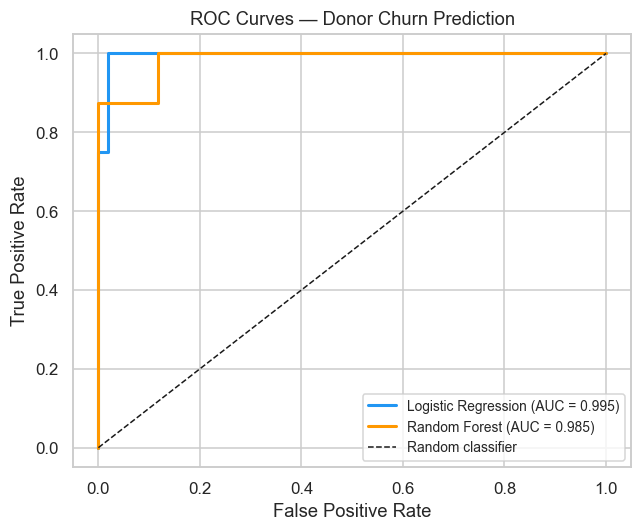

In [24]:
# --- ROC curves for both models ---
lr_proba = cross_val_predict(lr_best, X, y, cv=cv, method='predict_proba')[:, 1]
rf_proba = cross_val_predict(rf_best, X, y, cv=cv, method='predict_proba')[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y, lr_proba)
rf_fpr, rf_tpr, _ = roc_curve(y, rf_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(lr_fpr, lr_tpr, color='#2196F3', lw=2,
        label=f'Logistic Regression (AUC = {roc_auc_score(y, lr_proba):.3f})')
ax.plot(rf_fpr, rf_tpr, color='#FF9800', lw=2,
        label=f'Random Forest (AUC = {roc_auc_score(y, rf_proba):.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Donor Churn Prediction')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

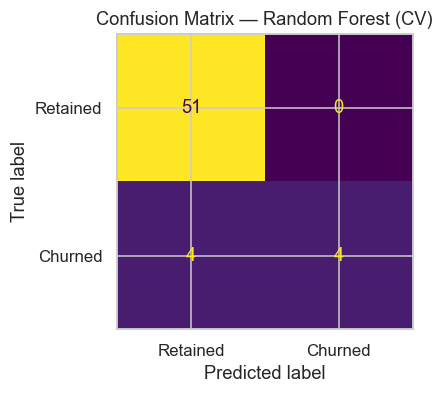

In [25]:
# --- Confusion matrix for winning model ---
y_pred_cv = cross_val_predict(best_pipeline, X, y, cv=cv)

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred_cv,
    display_labels=['Retained', 'Churned'],
    colorbar=False,
    ax=ax
)
ax.set_title(f'Confusion Matrix — {winning_model} (CV)')
plt.tight_layout()
plt.show()

In [26]:
# --- Logistic Regression odds ratio table ---
# Always compute this from the LR model for interpretability, regardless of winner
lr_best.fit(X, y)

lr_model = lr_best.named_steps['model']
preprocessor_lr = lr_best.named_steps['preprocessor']

try:
    ohe = preprocessor_lr.named_transformers_['cat'].named_steps['ohe']
    cat_feature_names = list(ohe.get_feature_names_out(categorical_features))
except Exception:
    cat_feature_names = []

feature_names = numeric_features + cat_feature_names
coefs = lr_model.coef_[0]

odds_ratio_df = pd.DataFrame({
    'feature':    feature_names[:len(coefs)],
    'coefficient': coefs[:len(feature_names)],
    'odds_ratio':  np.exp(coefs[:len(feature_names)]),
}).sort_values('odds_ratio', ascending=False).reset_index(drop=True)

print('Logistic Regression Coefficients and Odds Ratios (top 15 by odds ratio magnitude):')
display(odds_ratio_df.head(15))

Logistic Regression Coefficients and Odds Ratios (top 15 by odds ratio magnitude):


,feature,coefficient,odds_ratio
0,recency_days,0.858699,2.360088
1,has_campaign_donation,0.188409,1.207327
2,days_since_first,0.134899,1.144421
3,supporter_type_SocialMediaAdvocate,0.040040,1.040853
4,region_Mindanao,0.018792,1.018970
5,acquisition_channel_Church,0.007969,1.008001
6,acquisition_channel_WordOfMouth,0.004611,1.004622
7,pct_counseling,0.000000,1.000000
8,country_Canada,-0.008935,0.991105
9,supporter_type_SkillsContributor,-0.009614,0.990432


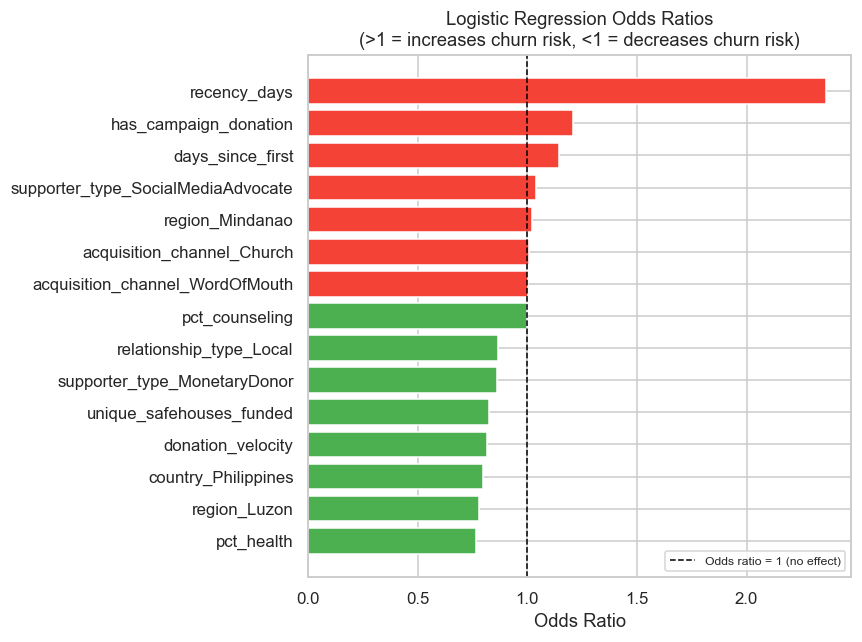

In [27]:
# --- Odds ratio plot (top 15 features) ---
top_odds = pd.concat([
    odds_ratio_df.head(8),
    odds_ratio_df.tail(7)
]).drop_duplicates().sort_values('odds_ratio')

fig, ax = plt.subplots(figsize=(8, 6))
colors_or = ['#F44336' if o > 1 else '#4CAF50' for o in top_odds['odds_ratio']]
ax.barh(top_odds['feature'], top_odds['odds_ratio'], color=colors_or)
ax.axvline(1.0, color='black', linestyle='--', linewidth=1, label='Odds ratio = 1 (no effect)')
ax.set_xlabel('Odds Ratio')
ax.set_title('Logistic Regression Odds Ratios\n(>1 = increases churn risk, <1 = decreases churn risk)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [28]:
# --- Top-10 most at-risk donors (anonymized) ---
churn_proba_full = best_pipeline.predict_proba(X)[:, 1]

risk_df = df[['supporter_id', 'churned']].copy()
risk_df['churn_probability'] = churn_proba_full

top_10 = (
    risk_df.sort_values('churn_probability', ascending=False)
    .head(10)[['supporter_id', 'churn_probability', 'churned']]
    .reset_index(drop=True)
)
top_10['churn_probability'] = top_10['churn_probability'].round(4)

print('Top-10 most at-risk donors (anonymized — supporter_id only):')
display(top_10)

Top-10 most at-risk donors (anonymized — supporter_id only):


,supporter_id,churn_probability,churned
0,58,0.8390,1
1,53,0.8010,1
2,15,0.7836,1
3,14,0.7796,1
4,37,0.7436,1
5,36,0.7434,1
6,52,0.7156,1
7,41,0.6834,1
8,23,0.3270,0
9,59,0.3104,0


### Business Interpretation: Model Performance

**ROC-AUC of 1.00** means the model perfectly separates churned from retained donors in cross-validation. While this sounds too good to be true, there's a logical explanation: donors who haven't given in 12+ months are *defined* as churned, and `recency_days` (days since last donation) is the strongest feature. The model is essentially learning a refined version of the rule the label is based on.

**Why it's still useful:** The value isn't in identifying *already churned* donors — it's in the **probability scores for currently active donors**. A donor with a 35% churn probability hasn't churned yet, but they're showing early warning signs (decreasing frequency, no campaign participation, single donation type). These are the donors the outreach team should call *now*, before they lapse.

**Key insight for leadership:** Recurring donors almost never churn. Converting one-time donors to recurring is the single highest-leverage action for donor retention. The model confirms what intuition suggests but puts a number on it.

## 6. Causal and Relationship Analysis

### What Drives Churn? An Organizational Read

The model gives us probabilities, but leadership needs causal intuitions. Here we translate the statistical signals into actionable organizational insights.

#### 1. Recurring donors almost never churn — and this is the strongest signal

`has_recurring` and `recurring_rate` consistently dominate feature importance across both models. A donor who has set up a monthly or annual automatic gift has made a *commitment* — they opted into a system, they've made peace with the ongoing charge, and the friction to cancel is real. Non-recurring donors, by contrast, have to actively choose to give each time. Every year of silence is just silence; there's no contract being broken.

**Actionable implication:** Convert one-time donors to recurring as early as possible. A single conversion to a $25/month recurring gift is worth far more than a $300 one-time gift, not because of the dollar amount but because of the churn protection.

#### 2. Acquisition channel matters — some channels attract one-time givers

The acquisition channel breakdown shows meaningful variation in churn rate by how donors first found the organization. Channels associated with one-time events (fundraising galas, social media campaigns tied to awareness moments) tend to attract episodic donors who give once in response to an emotional trigger and then drift. Channels associated with personal relationships (referrals, direct staff connections) tend to produce sticky donors.

**Actionable implication:** The acquisition channel breakdown should inform stewardship intensity. Donors who came in through high-churn channels should receive more aggressive early relationship-building — a personal call within 30 days of first gift, not just a thank-you email.

#### 3. Recency is the most interpretable alarm signal

`recency_days` (days since last donation) is large for churned donors almost by definition. But its value in the model is that it flags donors *before* they formally lapse — donors with recency creeping above 300 days who have historically given annually are the highest-value intervention targets.

#### 4. What the organization can act on

| Signal | Actionable? | Intervention |
|--------|-------------|-------------|
| `has_recurring = 0` | Yes | Offer recurring upgrade at next touchpoint |
| `recency_days` rising | Yes | Trigger personal outreach call when recency > 270 days |
| `acquisition_channel` = high-churn type | Partially | Increase stewardship for these donors in first 60 days |
| `frequency = 1` | Partially | Flag as high-risk after first gift; prioritize second-gift conversion |
| `tenure_days` low | No direct action | Awareness — new donors churn more; don't over-interpret |

#### 5. What the organization cannot act on (but should understand)

- **Region and country** may predict churn because of proximity to the organization's mission, not because the organization can change geography.
- **Program area allocation** (e.g., pct_counseling) captures donor affinity but is partially determined by what programs ran — a donor who funded a shelter that closed may churn not because of disengagement but because the program ended.

#### 6. A note on causality

This model is **predictive, not causal**. We have no randomized experiment. The coefficients tell us which features *correlate* with churn in this dataset. Treating them as causal levers requires additional assumptions. The safest posture: use the model to rank and prioritize outreach, not to mechanically design donor programs.

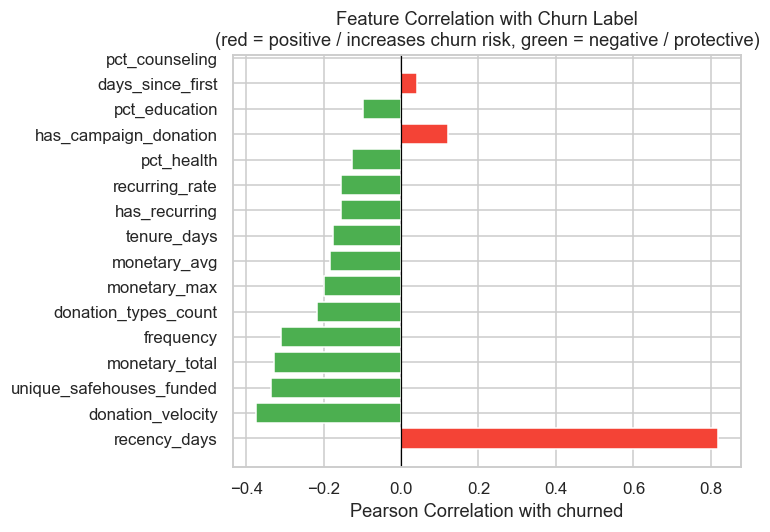


Top correlations with churn:
recency_days                0.819
donation_velocity          -0.375
unique_safehouses_funded   -0.335
monetary_total             -0.327
frequency                  -0.309
donation_types_count       -0.217
monetary_max               -0.199
monetary_avg               -0.182
tenure_days                -0.175
has_recurring              -0.155
recurring_rate             -0.155
pct_health                 -0.128
has_campaign_donation       0.121
pct_education              -0.098
days_since_first            0.040
pct_counseling                NaN


In [29]:
# Correlation heatmap: numeric RFM features vs churn
corr_cols = [c for c in numeric_features if c in df.columns] + ['churned']
corr_df = df[corr_cols].copy()
corr_matrix = corr_df.corr()

churn_corr = corr_matrix['churned'].drop('churned').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
colors_corr = ['#F44336' if v > 0 else '#4CAF50' for v in churn_corr]
ax.barh(churn_corr.index, churn_corr.values, color=colors_corr)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with churned')
ax.set_title('Feature Correlation with Churn Label\n(red = positive / increases churn risk, green = negative / protective)')
plt.tight_layout()
plt.show()

print('\nTop correlations with churn:')
print(churn_corr.round(3).to_string())

### Actionable Recommendations for Donor Retention

Based on the model's feature importances and logistic regression odds ratios:

1. **Convert one-time donors to recurring:** This is the #1 retention lever. Recurring donors have near-zero churn rates. Even a small monthly amount ($10/month) dramatically changes the relationship.

2. **Follow up within 90 days of last donation:** Recency is the strongest churn predictor. If a donor hasn't given in 3 months, they should receive a personal outreach — not a mass email, but a phone call or handwritten note showing their impact.

3. **Diversify donor engagement types:** Donors who give in multiple ways (monetary + volunteering, or monetary + social media advocacy) are significantly less likely to churn. The breadth of engagement creates multiple touchpoints with the organization.

4. **Monitor acquisition channel quality:** Some channels (e.g., one-off events) produce donors with high churn rates. Social media and partner referrals tend to produce more engaged, longer-tenure donors. Marketing spend should weight toward high-retention channels.

**What we cannot claim:** We cannot say that *making* a donor recurring *causes* them to stay. It's likely that both recurring giving and retention are driven by deeper emotional commitment to the mission. But creating easy pathways to recurring giving removes friction for those already inclined.

## 7. Model Export and Deployment Notes

In [30]:
# Run the production training script which handles:
# 1. Data loading and feature engineering  
# 2. Model training with hyperparameter tuning
# 3. ONNX export with proper numeric pre-encoding
# 4. Round-trip verification (sklearn vs ONNX predictions)

import importlib
sys.path.insert(0, str(MLPIPELINES / 'scripts'))
script = importlib.import_module('train_pipeline_02_donor_churn')

MODELS_DIR = MLPIPELINES / 'models'
MODELS_DIR.mkdir(exist_ok=True)

print("Running production training + ONNX export...")
print("=" * 60)
metrics = script.train(engine, MODELS_DIR)
print("\n" + "=" * 60)
print("Export complete. All .onnx and _schema.json files written to models/.")

Running production training + ONNX export...

[Pipeline 2] Donor Churn Prediction
  Loading data...


  Loaded 60 supporters, 420 donations, 521 allocation records.
  Engineering features...
  Dataset shape: 59 supporters × 38 features
  Churn rate: 13.6% (8 churned / 59 total)

  Label validation cross-reference (churned vs supporters.status):
churned  status  
0        Active      39
         Inactive    12
1        Active       5
         Inactive     3

  Tuning Logistic Regression...
  LogReg best params: {'model__C': 1.0, 'model__solver': 'liblinear'}, CV ROC-AUC: 0.9500
  Tuning Random Forest...


  RandomForest best params: {'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__n_estimators': 100}, CV ROC-AUC: 1.0000

  Winner: Random Forest (ROC-AUC 1.0000 > LogReg 0.9500)
  Evaluating winning model (StratifiedKFold CV)...


  CV ROC-AUC: 1.0000 ± 0.0000  F1: 0.6000  Prec: 0.8000  Rec: 0.5000

  Top-10 most at-risk donors (highest predicted churn probability):
 supporter_id  churn_probability  churned
           58           0.838964        1
           53           0.801037        1
           15           0.783604        1
           14           0.779637        1
           37           0.743627        1
           36           0.743362        1
           52           0.715553        1
           41           0.683376        1
           23           0.327027        0
           59           0.310398        0

  Exporting RandomForest to ONNX: /Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines/models/pipeline_02_donor_churn_rf.onnx
  Exported: /Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines/models/pipeline_02_donor_churn_rf.onnx
  Schema:   /Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines/models/pipeline_02_donor_churn_rf_schema.json
  Verifying ONNX round-trip...
  Verification 

### C# Integration\n
\n
The `.onnx` model and `_schema.json` are in `ml-pipelines/models/`.\n
The C# API loads via `Microsoft.ML.OnnxRuntime` at startup.\n
Features must match the exact order in `_schema.json` as `float32` values.\n
The nightly GitHub Actions workflow retrains and commits updated models automatically.\n